In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
U = np.random.uniform(0,1,1)

In [3]:
def bernoulli(amostra,p):
  amostra = []
  u = np.random.uniform(0,1,1000)
  for i in range(1000):
    if u[i] < p:
      amostra.append(1)
    else:
      amostra.append(0)
  return amostra

In [4]:
a=bernoulli(U,0.7)
len(a)

1000

In [5]:
p = 0.95
n = 100

def ingenuo(n,p):
    amostra= []
    for i in range(n):
      uniforme = np.random.uniform(size=n)
      binomial = np.sum(uniforme <p)
      amostra.append(binomial)
    return(amostra)


In [6]:
#criei funções do método ingenuo e recursivo para testar o tempo deles, para 100 repetições.
def recursivo(n,p):
    #p = 0.5
    #n = 100
    amostra = []
    for j in range(100):
        i = 0
        pi = (1-p)**n
        F = pi
        uni = np.random.uniform(0,1,size = 1)
        while uni>F:
            pi= ((n-i)/(i+1))*(p/(1-p))*pi
            i+=1
            F+=pi
        amostra.append(i)
    return(amostra)



In [7]:
recursivo(100,0.5)

[54,
 46,
 51,
 48,
 44,
 52,
 40,
 54,
 43,
 52,
 49,
 49,
 55,
 54,
 46,
 49,
 53,
 45,
 50,
 45,
 46,
 47,
 46,
 40,
 52,
 50,
 46,
 54,
 50,
 44,
 57,
 42,
 46,
 50,
 37,
 50,
 49,
 57,
 47,
 44,
 42,
 53,
 49,
 37,
 59,
 50,
 58,
 49,
 57,
 42,
 48,
 52,
 63,
 53,
 48,
 53,
 48,
 54,
 47,
 43,
 50,
 60,
 43,
 54,
 50,
 43,
 54,
 48,
 43,
 46,
 58,
 51,
 43,
 56,
 49,
 45,
 51,
 49,
 42,
 54,
 48,
 51,
 49,
 48,
 48,
 56,
 45,
 53,
 52,
 42,
 53,
 50,
 44,
 40,
 45,
 43,
 52,
 45,
 53,
 55]

É possível ver que o método recursivo é pior para p próximos de 1, pois exigem mais iterações, agora o ingenuo é constante na maioria dos casos.

In [8]:
valores_p = np.linspace(0.1,0.9,9)
met_ingenuo = []
for p in valores_p:
    inicio = time.time()
    ingenuo(100,p)
    fim = time.time()
    met_ingenuo.append((fim-inicio)/100)
print(met_ingenuo)


[2.123594284057617e-05, 1.566171646118164e-05, 1.4486312866210937e-05, 1.6510486602783203e-05, 1.421213150024414e-05, 1.4107227325439454e-05, 1.485586166381836e-05, 1.3844966888427734e-05, 1.356363296508789e-05]


In [9]:
valores_p = np.linspace(0.1,0.9,9)
met_recursivo = []
for p in valores_p:
    inicio = time.time()
    recursivo(100,p)
    fim = time.time()
    met_recursivo.append((fim-inicio)/100)
print(met_recursivo)

[0.00114243745803833, 4.446983337402344e-05, 6.450891494750976e-05, 9.364128112792969e-05, 0.00010142326354980468, 0.00013051509857177733, 0.00014825820922851563, 0.0001508021354675293, 0.00017774105072021484]


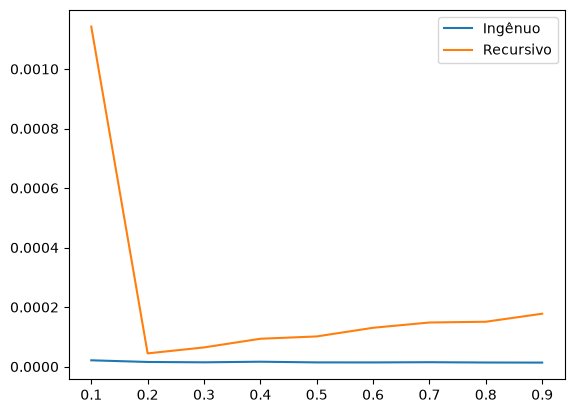

In [10]:
plt.plot(valores_p, met_ingenuo, label='Ingênuo')
plt.plot(valores_p, met_recursivo, label='Recursivo')
plt.legend()
plt.show()


Fica claro pelo gráfico que o ingênuo coninua constante enquanto o recursivo quando aumenta p ele vai aumentando o tempo de execução.
